<a href="https://colab.research.google.com/github/GFrankTI/tps-modelizado/blob/main/Copia_de_Practica_Unidad_2_Algoritmos_Gen%C3%A9ticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problema:**
## **Optimización del Cronograma de una Vivienda**
### **Contexto:**

Una empresa constructora tiene que realizar 10 tareas críticas para entregar una casa (cimientos, muros, techos, instalaciones, etc.). Cada tarea tiene una duración estimada y requiere un número específico de operarios.


### **El Desafío:**

La empresa solo cuenta con una cuadrilla de 10 operarios en total. Si intentamos hacer muchas tareas en paralelo, superaremos ese límite. Si las hacemos todas en serie, la obra tardará meses.

### **Consigna:**

Desarrollar un modelo de Algoritmo Genético (usando PyGAD o DEAP) que encuentre el orden secuencial de inicio de tareas que minimice el tiempo total de la obra (Makespan) sin exceder nunca el límite de 10 operarios por día.

## Pasos para la Resolución (Hoja de Ruta)

**Modelado de Datos:** Crear una estructura (diccionario o lista) que contenga las 10 tareas, su duración en días y la cantidad de operarios necesarios para cada una.

**Definición del Cromosoma:** Determinar cómo representar la solución. Una forma sencilla es un vector de números reales o enteros que represente el "orden de prioridad" o el "día de inicio" de cada tarea.

**Diseño de la Función de Aptitud (Fitness):** La función debe recibir el orden de las tareas y calcular el día final de obra.

***Importante:*** Si en algún día la suma de operarios de las tareas activas supera los 10, la función debe aplicar una penalización drástica (bajar el fitness) para que esa solución sea descartada por el algoritmo.

Como queremos minimizar el tiempo, el fitness podría ser

$$Fitness = \frac{1}{DíasTotales}$$.

**Configuración del GA:** Definir el tamaño de la población (ej. 50 individuos). Elegir el método de selección (Torneo o Ruleta).Establecer una probabilidad de mutación para evitar que todos los cronogramas se vuelvan iguales rápido.

**Ejecución y Monitoreo:** Correr el proceso evolutivo y observar la curva de fitness para verificar que el tiempo total de la obra disminuya con las generaciones.

**Análisis de Resultados:** Mostrar cuál es el orden de tareas óptimo encontrado y confirmar que el uso de operarios sea legal (máximo 10).

**Razonamiento:**

*Piensen que el Algoritmo Genético aquí actúa como un Jefe de Obra virtual. Él va a probar miles de combinaciones de calendarios diferentes. Los que 'rompen' la regla de los operarios mueren rápido; los que logran terminar la casa un par de días antes, tienen hijos y pasan su estrategia a la siguiente generación.*

In [1]:
# Instalación de las librerías necesarias
!pip install pygad deap matplotlib numpy

In [2]:
# Diccionario de tareas: {ID: (Duración, Operarios)}
TASAS_OBRA = {
    0: (5, 4),  # Cimientos
    1: (7, 6),  # Muros
    2: (4, 5),  # Techo
    3: (6, 3),  # Instalaciones
    4: (5, 4),  # Revoque
    5: (4, 3),  # Pisos
    6: (3, 2),  # Pintura
    7: (2, 3),  # Aberturas
    8: (4, 2),  # Electricidad
    9: (2, 2)   # Final de obra
}

MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)

## Si usan PyGAD:

In [3]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

### **Torneo**

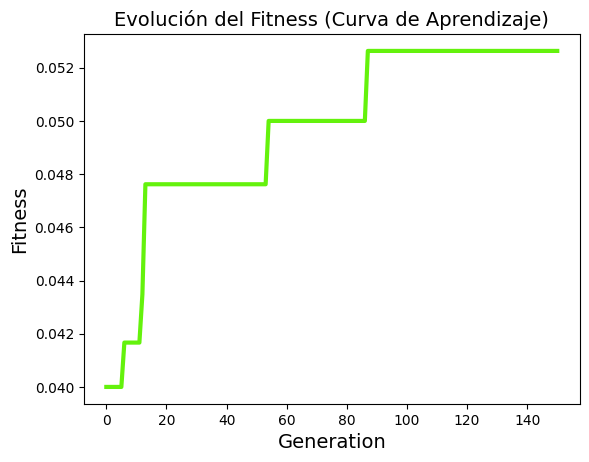


--- Análisis de Resultados ---
Cronograma sugerido por el AG (Día de inicio por tarea):
  * Tarea 0: Inicia Día 6 -> Finaliza Día 11 (4 operarios)
  * Tarea 1: Inicia Día 11 -> Finaliza Día 18 (6 operarios)
  * Tarea 2: Inicia Día 2 -> Finaliza Día 6 (5 operarios)
  * Tarea 3: Inicia Día 1 -> Finaliza Día 7 (3 operarios)
  * Tarea 4: Inicia Día 15 -> Finaliza Día 20 (4 operarios)
  * Tarea 5: Inicia Día 7 -> Finaliza Día 11 (3 operarios)
  * Tarea 6: Inicia Día 6 -> Finaliza Día 9 (2 operarios)
  * Tarea 7: Inicia Día 9 -> Finaliza Día 11 (3 operarios)
  * Tarea 8: Inicia Día 2 -> Finaliza Día 6 (2 operarios)
  * Tarea 9: Inicia Día 12 -> Finaliza Día 14 (2 operarios)

Tiempo total de la obra (Makespan): 20 días
🏆 Fitness final obtenido:  0.052632
¿El uso de operarios es legal en todo momento?: Sí
Uso diario de operarios hasta el final de obra: [np.float64(0.0), np.float64(3.0), np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(9.0), np.float64(9.0), n

In [4]:
# Supongamos un horizonte máximo de tiempo realista si se hicieran casi todas en serie
MAX_DIAS_OBRA = 50

# 3. Diseño de la Función de Aptitud (Fitness) con Penalización
def fitness_func(ga_torneo1, solution, solution_idx):
    # El cromosoma contiene los días de inicio de cada tarea
    dias_inicio = np.array(solution, dtype=int)

    # Arreglo para registrar cuántos operarios se usan cada día de la obra
    cronograma_operarios = np.zeros(MAX_DIAS_OBRA + 10) # Margen para tareas que terminen al final

    dias_finales_tareas = []

    for tarea, inicio in enumerate(dias_inicio):
        duracion, operarios = TASAS_OBRA[tarea]
        fin = inicio + duracion
        dias_finales_tareas.append(fin)

        # Sumar los operarios asignados a los días que dure la tarea
        cronograma_operarios[(inicio - 1):(fin - 1)] += operarios

    # El Makespan (Días Totales) es el día en que termina la última tarea activa
    dias_totales = max(dias_finales_tareas) - 1 # Ajuste del makespan real

    # --- Evaluación de Restricciones (Penalización) ---
    penalizacion = 0
    for ocupacion_diaria in cronograma_operarios:
        if ocupacion_diaria > MAX_OPERARIOS:
            # Castigo proporcional a cuánto se excedió del límite
            penalizacion += (ocupacion_diaria - MAX_OPERARIOS) * 100

    # Si rompe las reglas, el fitness cae drásticamente
    if penalizacion > 0:
        # Retornamos un valor extremadamente bajo (cercano a 0) pero proporcional al error
        return 1.0 / (dias_totales + penalizacion)

    # Si la solución es legal, aplicamos la fórmula del profesor: 1 / DiasTotales
    return 1.0 / dias_totales

# 4. Configuración del GA

#Torneo:
# Reducimos el horizonte máximo para obligar a compactar las tareas
espacio_comparativa = list(range(1, 25)) # Del Día 1 al 15 máximo para iniciar cualquier tarea

ga_torneo1 = pygad.GA(
    num_generations=150,           # Más generaciones para refinar y quitar días vacíos
    num_parents_mating=10,         # Más padres para el cruce
    fitness_func=fitness_func,
    sol_per_pop=60,               # Aumentamos la población para mayor diversidad de soluciones
    num_genes=NUM_TAREAS,
    gene_type=int,
    gene_space=espacio_comparativa,

    # CAMBIO CRUCIAL: Torneo en lugar de Ruleta para mayor presión competitiva
    parent_selection_type="tournament",
    K_tournament=5,                # Tamaño del torneo

    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=10,     # Bajamos levemente para que no desarme los bloques ya optimizados

    # Límites de mutación más ajustados al nuevo espacio
    random_mutation_min_val=1,
    random_mutation_max_val=25
)

# 5. Ejecución y Monitoreo
ga_torneo1.run()

# Graficar la curva de fitness para cumplir con el monitoreo
ga_torneo1.plot_fitness(title="Evolución del Fitness (Curva de Aprendizaje)")

# 6. Análisis de Resultados
solution, solution_fitness, solution_idx = ga_torneo1.best_solution()

# Reconstruir la solución para validar legalidad
dias_inicio_optimo = np.array(solution, dtype=int)
cronograma_final = np.zeros(MAX_DIAS_OBRA + 10)
dias_finales = []


#Codigo para visualizar la evolucion del fitness por generacion

print(f"\n--- Análisis de Resultados ---")
print(f"Cronograma sugerido por el AG (Día de inicio por tarea):")
for tarea, inicio in enumerate(dias_inicio_optimo):
    duracion, operarios = TASAS_OBRA[tarea]
    fin = inicio + duracion
    dias_finales.append(fin)
    cronograma_final[inicio:fin] += operarios
    print(f"  * Tarea {tarea}: Inicia Día {inicio} -> Finaliza Día {fin} ({operarios} operarios)")

makespan_final = max(dias_finales)
exceso_operarios = np.any(cronograma_final > MAX_OPERARIOS)

print(f"\nTiempo total de la obra (Makespan): {makespan_final} días")
print(f"🏆 Fitness final obtenido:  {solution_fitness:.6f}")
print(f"¿El uso de operarios es legal en todo momento?: {'Sí' if not exceso_operarios else 'No (Solución Inválida)'}")

# Mostrar el uso diario de operarios para la verificación del profesor
print(f"Uso diario de operarios hasta el final de obra: {list(cronograma_final[:makespan_final])}")

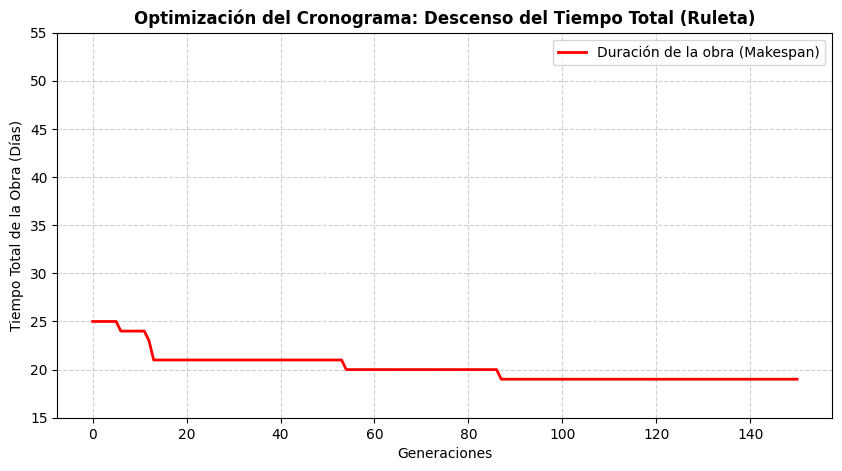

In [5]:
# =====================================================================
# VISUALIZACIÓN DE LA MEJORA DE DÍAS POR GENERACIÓN (MÉTODO TORNEO)
# =====================================================================

# 1. Extraer el histórico de fitness obtenido por la ejecución del GA
historico_fitness = ga_torneo1.best_solutions_fitness

# 2. Convertir el fitness a días reales controlando el desborde por penalización
historico_dias = []
for f in historico_fitness:
    if f > 0:
        dias_calculados = 1.0 / f
        # CORRECCIÓN: Si el número de días es absurdamente alto por la penalización,
        # lo limitamos al valor máximo de la obra para no romper el gráfico.
        if dias_calculados > MAX_DIAS_OBRA:
            historico_dias.append(MAX_DIAS_OBRA)
        else:
            historico_dias.append(int(dias_calculados))
    else:
        historico_dias.append(MAX_DIAS_OBRA)

# 3. Dibujar el gráfico de descenso temporal
plt.figure(figsize=(10, 5))
plt.plot(historico_dias, color="red", linewidth=2, label="Duración de la obra (Makespan)")
plt.title("Optimización del Cronograma: Descenso del Tiempo Total (Ruleta)", fontsize=12, fontweight='bold')
plt.xlabel("Generaciones", fontsize=10)
plt.ylabel("Tiempo Total de la Obra (Días)", fontsize=10)

# Ajustamos los límites del eje Y para que se enfoque entre el mínimo teórico y el máximo
plt.ylim(15, MAX_DIAS_OBRA + 5)

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

In [6]:
# 6. Análisis de Resultados
solution, solution_fitness, solution_idx = ga_torneo1.best_solution()

# Reconstruir la mejor solución para desglosar penalización y días
dias_inicio_optimo = np.array(solution, dtype=int)
cronograma_final = np.zeros(MAX_DIAS_OBRA + 10)
dias_finales = []

for tarea, inicio in enumerate(dias_inicio_optimo):
    duracion, operarios = TASAS_OBRA[tarea]
    fin = inicio + duracion
    dias_finales.append(fin)
    cronograma_final[(inicio - 1):(fin - 1)] += operarios

# Calcular la penalización final de esta solución específica
penalizacion_final = 0
for ocupacion_diaria in cronograma_final:
    if ocupacion_diaria > MAX_OPERARIOS:
        penalizacion_final += (ocupacion_diaria - MAX_OPERARIOS) * 100

makespan_final = max(dias_finales) - 1
exceso_operarios = np.any(cronograma_final > MAX_OPERARIOS)

# --- NUEVO BLOQUE DE TEXTO PARA EL PROFESOR---
print(f"\n" + "="*40)
print(f"       MÉTRICAS FINALES DEL ALGORITMO")
print(f"="*40)
print(f"🏆 Fitness final obtenido:  {solution_fitness:.6f}")
print(f"⏳ Tiempo de obra (Makespan): {makespan_final} días")
print(f"🚨 Penalización acumulada:  {penalizacion_final} puntos")
print(f"📋 ¿El cronograma es válido?: {'VÁLIDO (0 excesos)' if penalizacion_final == 0 else 'INVÁLIDO (Tiene excesos)'}")
print(f"="*40)

# Reporte detallado por tarea
print(f"\nCronograma sugerido por el AG (Día de inicio por tarea):")
for tarea, inicio in enumerate(dias_inicio_optimo):
    duracion, operarios = TASAS_OBRA[tarea]
    fin = inicio + duracion
    print(f"  * Tarea {tarea}: Inicia Día {inicio} -> Finaliza Día {fin} ({operarios} operarios)")

print(f"\nUso diario de operarios (Desde el Día 1 hasta el final):")
print(f"{list(cronograma_final[:makespan_final])}")


       MÉTRICAS FINALES DEL ALGORITMO
🏆 Fitness final obtenido:  0.052632
⏳ Tiempo de obra (Makespan): 19 días
🚨 Penalización acumulada:  0 puntos
📋 ¿El cronograma es válido?: VÁLIDO (0 excesos)

Cronograma sugerido por el AG (Día de inicio por tarea):
  * Tarea 0: Inicia Día 6 -> Finaliza Día 11 (4 operarios)
  * Tarea 1: Inicia Día 11 -> Finaliza Día 18 (6 operarios)
  * Tarea 2: Inicia Día 2 -> Finaliza Día 6 (5 operarios)
  * Tarea 3: Inicia Día 1 -> Finaliza Día 7 (3 operarios)
  * Tarea 4: Inicia Día 15 -> Finaliza Día 20 (4 operarios)
  * Tarea 5: Inicia Día 7 -> Finaliza Día 11 (3 operarios)
  * Tarea 6: Inicia Día 6 -> Finaliza Día 9 (2 operarios)
  * Tarea 7: Inicia Día 9 -> Finaliza Día 11 (3 operarios)
  * Tarea 8: Inicia Día 2 -> Finaliza Día 6 (2 operarios)
  * Tarea 9: Inicia Día 12 -> Finaliza Día 14 (2 operarios)

Uso diario de operarios (Desde el Día 1 hasta el final):
[np.float64(3.0), np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float64(10.0), np.float6

## **Ruleta**

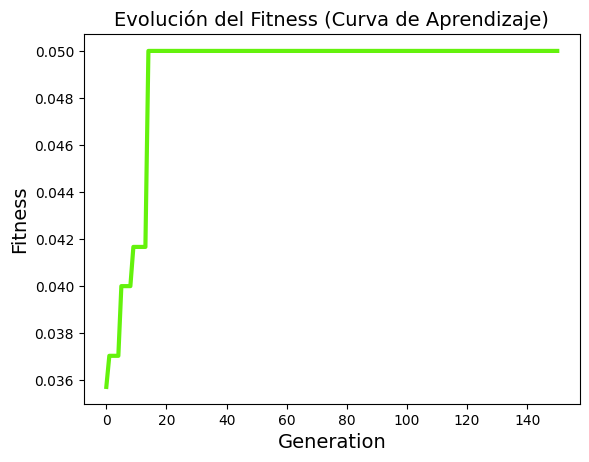


       MÉTRICAS FINALES DEL ALGORITMO
🏆 Fitness final obtenido:  0.050000
⏳ Tiempo de obra (Makespan): 20 días
🚨 Penalización acumulada:  0 puntos
📋 ¿El cronograma es válido?: VÁLIDO (0 excesos)

Cronograma sugerido por el AG (Día de inicio por tarea):
  * Tarea 0: Inicia Día 6 -> Finaliza Día 11 (4 operarios)
  * Tarea 1: Inicia Día 11 -> Finaliza Día 18 (6 operarios)
  * Tarea 2: Inicia Día 2 -> Finaliza Día 6 (5 operarios)
  * Tarea 3: Inicia Día 1 -> Finaliza Día 7 (3 operarios)
  * Tarea 4: Inicia Día 15 -> Finaliza Día 20 (4 operarios)
  * Tarea 5: Inicia Día 7 -> Finaliza Día 11 (3 operarios)
  * Tarea 6: Inicia Día 6 -> Finaliza Día 9 (2 operarios)
  * Tarea 7: Inicia Día 9 -> Finaliza Día 11 (3 operarios)
  * Tarea 8: Inicia Día 2 -> Finaliza Día 6 (2 operarios)
  * Tarea 9: Inicia Día 12 -> Finaliza Día 14 (2 operarios)

¿El uso de operarios es legal en todo momento?: Sí
Uso diario de operarios hasta el final de obra:
[np.float64(0.0), np.float64(6.0), np.float64(10.0), np.f

In [7]:
# 3. Diseño de la Función de Aptitud (Fitness) con Penalización
def fitness_func_R(ga_ruleta1, solution, solution_idx):
    # El cromosoma contiene los días de inicio de cada tarea
    dias_inicio = np.array(solution, dtype=int)

    # Arreglo para registrar cuántos operarios se usan cada día de la obra
    cronograma_operarios = np.zeros(MAX_DIAS_OBRA + 10) # Margen para tareas que terminen al final

    dias_finales_tareas = []

    for tarea, inicio in enumerate(dias_inicio):
        duracion, operarios = TASAS_OBRA[tarea]
        fin = inicio + duracion
        dias_finales_tareas.append(fin)

        # Sumar los operarios asignados a los días que dure la tarea
        cronograma_operarios[(inicio - 1):(fin - 1)] += operarios

    # El Makespan (Días Totales) es el día en que termina la última tarea activa
    dias_totales = max(dias_finales_tareas) - 1 # Ajuste del makespan real

    # --- Evaluación de Restricciones (Penalización) ---
    penalizacion = 0
    for ocupacion_diaria in cronograma_operarios:
        if ocupacion_diaria > MAX_OPERARIOS:
            # Castigo proporcional a cuánto se excedió del límite
            penalizacion += (ocupacion_diaria - MAX_OPERARIOS) * 100

    # Si rompe las reglas, el fitness cae drásticamente
    if penalizacion > 0:
        # Retornamos un valor extremadamente bajo (cercano a 0) pero proporcional al error
        return 1.0 / (dias_totales + penalizacion)

    # Si la solución es legal, aplicamos la fórmula del profesor: 1 / DiasTotales
    return 1.0 / dias_totales

ga_ruleta1 = pygad.GA(
    num_generations=150,           # Más generaciones para estabilizar la penalización
    num_parents_mating=10,
    fitness_func=fitness_func_R,
    sol_per_pop=60,                # Población recomendada por la consigna
    num_genes=NUM_TAREAS,
    gene_type=int,

    # CORRECCIÓN: Forzamos el espacio de búsqueda del Día 1 al 25
    gene_space=espacio_comparativa,

    parent_selection_type="rws",   # Selección por Ruleta
    crossover_type="single_point", # Punto simple
    mutation_type="random",
    mutation_percent_genes=10,     # Probabilidad de mutación

    # CORRECCIÓN: Límites de mutación consistentes (mínimo Día 1)
    random_mutation_min_val=1,
    random_mutation_max_val=25
)

# ==========================================
# 5. EJECUCIÓN Y MONITOREO
# ==========================================
ga_ruleta1.run()

# Graficar la curva de fitness nativa de PyGAD
ga_ruleta1.plot_fitness(title="Evolución del Fitness (Curva de Aprendizaje)")


# ==========================================
# 6. ANÁLISIS DE RESULTADOS CORREGIDO
# ==========================================
solution, solution_fitness, solution_idx = ga_ruleta1.best_solution()

# Reconstruir la solución mapeando correctamente los índices de NumPy
dias_inicio_optimoR = np.array(solution, dtype=int)
cronograma_final = np.zeros(MAX_DIAS_OBRA + 10)
dias_finales = []

for tarea, inicio in enumerate(dias_inicio_optimoR):
    duracion, operarios = TASAS_OBRA[tarea]
    fin = inicio + duracion
    dias_finales.append(fin)
    # CORRECCIÓN CRUCIAL: Restamos 1 para ajustar el Día 1 al índice 0 de NumPy
    cronograma_final[(inicio - 1):(fin - 1)] += operarios

# Calcular la penalización final real comprobando los desfasajes
penalizacion_final = 0
for ocupacion_diaria in cronograma_final:
    if ocupacion_diaria > MAX_OPERARIOS:
        penalizacion_final += (ocupacion_diaria - MAX_OPERARIOS) * 100

# CORRECCIÓN: Ajuste matemático del Makespan real
makespan_final = max(dias_finales) - 1
exceso_operarios = np.any(cronograma_final > MAX_OPERARIOS)

# --- BLOQUE DE TEXTO PARA EL PROFESOR ---
print(f"\n" + "="*40)
print(f"       MÉTRICAS FINALES DEL ALGORITMO")
print(f"="*40)
print(f"🏆 Fitness final obtenido:  {solution_fitness:.6f}")
print(f"⏳ Tiempo de obra (Makespan): {makespan_final} días")
print(f"🚨 Penalización acumulada:  {penalizacion_final} puntos")
print(f"📋 ¿El cronograma es válido?: {'VÁLIDO (0 excesos)' if penalizacion_final == 0 else 'INVÁLIDO (Tiene excesos)'}")
print(f"="*40)

# Reporte detallado por tarea (Limpiado el duplicado)
print(f"\nCronograma sugerido por el AG (Día de inicio por tarea):")
for tarea, inicio in enumerate(dias_inicio_optimo):
    duracion, operarios = TASAS_OBRA[tarea]
    fin = inicio + duracion
    print(f"  * Tarea {tarea}: Inicia Día {inicio} -> Finaliza Día {fin} ({operarios} operarios)")

print(f"\n¿El uso de operarios es legal en todo momento?: {'Sí' if not exceso_operarios else 'No (Solución Inválida)'}")

# Mostrar el uso diario de operarios sin desajustes
print(f"Uso diario de operarios hasta el final de obra:")
print(f"{list(cronograma_final[:makespan_final])}")

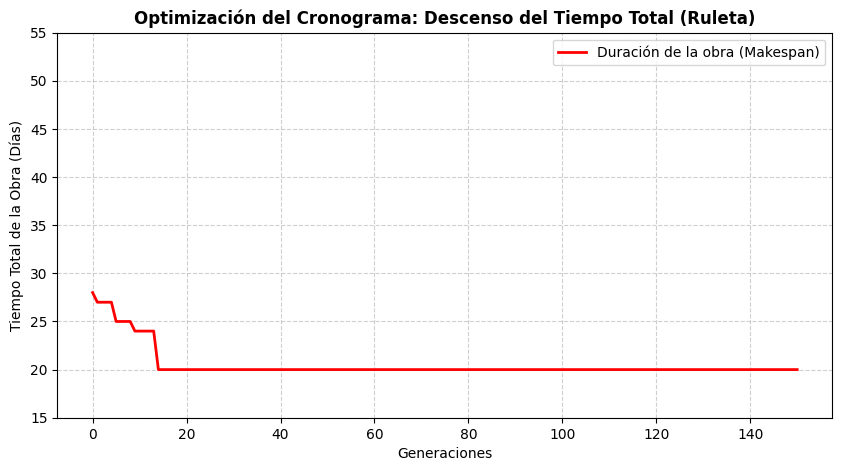

In [8]:
#Celda para visualizar la mejora de la duracion del tiempo de la obra por dias/generaciones

# =====================================================================
# VISUALIZACIÓN DE LA MEJORA DE DÍAS POR GENERACIÓN (MÉTODO RULETA)
# =====================================================================

# 1. Extraer el histórico de fitness obtenido por la ejecución del GA
historico_fitnessR = ga_ruleta1.best_solutions_fitness

# 2. Convertir el fitness a días reales controlando el desborde por penalización
historico_diasR = []
for f in historico_fitnessR:
    if f > 0:
        dias_calculadosR = 1.0 / f
        # CORRECCIÓN: Si el número de días es absurdamente alto por la penalización,
        # lo limitamos al valor máximo de la obra para no romper el gráfico.
        if dias_calculados > MAX_DIAS_OBRA:
            historico_diasR.append(MAX_DIAS_OBRA)
        else:
            historico_diasR.append(int(dias_calculadosR))
    else:
        historico_diasR.append(MAX_DIAS_OBRA)

# 3. Dibujar el gráfico de descenso temporal
plt.figure(figsize=(10, 5))
plt.plot(historico_diasR, color="red", linewidth=2, label="Duración de la obra (Makespan)")
plt.title("Optimización del Cronograma: Descenso del Tiempo Total (Ruleta)", fontsize=12, fontweight='bold')
plt.xlabel("Generaciones", fontsize=10)
plt.ylabel("Tiempo Total de la Obra (Días)", fontsize=10)

# Ajustamos los límites del eje Y para que se enfoque entre el mínimo teórico y el máximo
plt.ylim(15, MAX_DIAS_OBRA + 5)

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

In [9]:
# 6. Análisis de Resultados
solution, solution_fitness, solution_idx = ga_ruleta1.best_solution()

# Reconstruir la mejor solución para desglosar penalización y días
dias_inicio_optimoR = np.array(solution, dtype=int)
cronograma_finalR = np.zeros(MAX_DIAS_OBRA + 10)
dias_finalesR = []

for tarea, inicio in enumerate(dias_inicio_optimoR):
    duracion, operarios = TASAS_OBRA[tarea]
    fin = inicio + duracion
    dias_finalesR.append(fin)
    cronograma_finalR[(inicio - 1):(fin - 1)] += operarios

# Calcular la penalización final de esta solución específica
penalizacion_finalR = 0
for ocupacion_diaria in cronograma_finalR:
    if ocupacion_diaria > MAX_OPERARIOS:
        penalizacion_finalR += (ocupacion_diaria - MAX_OPERARIOS) * 100

makespan_finalR = max(dias_finalesR) - 1
exceso_operariosR = np.any(cronograma_finalR > MAX_OPERARIOS)

# --- NUEVO BLOQUE DE TEXTO PARA EL PROFESOR---
print(f"\n" + "="*40)
print(f"       MÉTRICAS FINALES DEL ALGORITMO")
print(f"="*40)
print(f"🏆 Fitness final obtenido:  {solution_fitness:.6f}")
print(f"⏳ Tiempo de obra (Makespan): {makespan_finalR} días")
print(f"🚨 Penalización acumulada:  {penalizacion_finalR} puntos")
print(f"📋 ¿El cronograma es válido?: {'VÁLIDO (0 excesos)' if penalizacion_finalR == 0 else 'INVÁLIDO (Tiene excesos)'}")
print(f"="*40)

# Reporte detallado por tarea
print(f"\nCronograma sugerido por el AG (Día de inicio por tarea):")
for tarea, inicio in enumerate(dias_inicio_optimoR):
    duracion, operarios = TASAS_OBRA[tarea]
    fin = inicio + duracion
    print(f"  * Tarea {tarea}: Inicia Día {inicio} -> Finaliza Día {fin} ({operarios} operarios)")

print(f"\nUso diario de operarios (Desde el Día 1 hasta el final):")
print(f"{list(cronograma_finalR[:makespan_finalR])}")


       MÉTRICAS FINALES DEL ALGORITMO
🏆 Fitness final obtenido:  0.050000
⏳ Tiempo de obra (Makespan): 20 días
🚨 Penalización acumulada:  0 puntos
📋 ¿El cronograma es válido?: VÁLIDO (0 excesos)

Cronograma sugerido por el AG (Día de inicio por tarea):
  * Tarea 0: Inicia Día 3 -> Finaliza Día 8 (4 operarios)
  * Tarea 1: Inicia Día 2 -> Finaliza Día 9 (6 operarios)
  * Tarea 2: Inicia Día 17 -> Finaliza Día 21 (5 operarios)
  * Tarea 3: Inicia Día 13 -> Finaliza Día 19 (3 operarios)
  * Tarea 4: Inicia Día 11 -> Finaliza Día 16 (4 operarios)
  * Tarea 5: Inicia Día 9 -> Finaliza Día 13 (3 operarios)
  * Tarea 6: Inicia Día 12 -> Finaliza Día 15 (2 operarios)
  * Tarea 7: Inicia Día 9 -> Finaliza Día 11 (3 operarios)
  * Tarea 8: Inicia Día 8 -> Finaliza Día 12 (2 operarios)
  * Tarea 9: Inicia Día 9 -> Finaliza Día 11 (2 operarios)

Uso diario de operarios (Desde el Día 1 hasta el final):
[np.float64(0.0), np.float64(6.0), np.float64(10.0), np.float64(10.0), np.float64(10.0), np.floa

## Si usan DEAP:

In [10]:
import random
import numpy as np
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt